Research Questions:
1) Which genres are the most common?
2) Which genres have the highest average budget and revenue?
3) Which genres have the highest average popularity?
4) Which genres have the highest number of movies with a voting average >= 8?

In [551]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [552]:
movies = pd.read_csv(r'C:\Users\emili\Downloads\imdb_movies.csv')
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [553]:
pd.set_option('display.max_columns', None) #making sure we can get all the columns


We have the following columns:
id, imdb_id, popularity, budget, revenue, original_title, cast, homepage, director, tagline, keywords, overview, runtime, genres, production_companies, release_date, vote_count, vote_average, release_year, budget_adj, revenue_adj

None of the questions involve cast, homepage, director, tagline, keywords, overview, runtime, production_companies, or release_date. I think runtime and release_date would still be interesting to look at though, so I'll drop the redudant columns I've identified

In [554]:
movies.drop(['cast', 'homepage', 'director', 'tagline', 'keywords', 'overview', 'production_companies'], axis = 1, inplace = True)
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


Before running any calculations I'll do a couple of quick checks to make sure I have to duplicates and I'm not missing any data

In [555]:
count = movies['original_title'].value_counts().to_frame()

In [556]:
count_repeated = count[count['count'] > 1]
count_repeated.head()

,count
original_title,
Hamlet,4
The Black Hole,3
Shelter,3
The Three Musketeers,3
Julia,3
...,...
The Guardian,2
Grey Gardens,2
King Solomon's Mines,2


In [557]:
movies.set_index('original_title', inplace=True)

In [558]:
movies.loc['Hamlet']

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
Hamlet,28238,tt1449175,0.086490,0,0,185,Drama,12/26/09,13,6.4,2009,0.000000e+00,0.000000e+00
Hamlet,10549,tt0116477,0.383469,0,0,242,Drama,12/25/96,51,6.7,1996,0.000000e+00,0.000000e+00
Hamlet,10688,tt0171359,0.277798,2000000,1568749,112,Drama,5/12/00,18,5.0,2000,2.532584e+06,1.986494e+06
Hamlet,10264,tt0099726,0.067973,0,20710451,130,Drama|History,12/19/90,43,6.5,1990,0.000000e+00,3.456364e+07


It looks like some original titles repeat

In [559]:
movies.loc['RoboCop']

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
RoboCop,97020,tt1234721,1.940735,120000000,239379423,102,Science Fiction|Action,1/30/14,1709,5.7,2014,1.105309e+08,2.204902e+08
RoboCop,5548,tt0093870,1.503371,13000000,53000000,102,Action|Thriller|Science Fiction,7/17/87,834,6.8,1987,2.494805e+07,1.017113e+08


I didn't know there were two robocop movies with the exact same title. My idea is to group by both the release year and the name to see if there are any duplicates that way. 

In [560]:
movies_grouped_dupe = movies.groupby(['original_title', 'release_year']).value_counts().to_frame()

In [561]:
movies_grouped_dupe[movies_grouped_dupe['count'] > 1]

,,,,,,,,,,,,,,count
original_title,release_year,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,budget_adj,revenue_adj,
TEKKEN,2010,42194,tt0411951,0.59643,30000000,967000,92,Crime|Drama|Action|Thriller|Science Fiction,3/20/10,110,5.0,30000000.0,967000.0,2


In [562]:
movies.loc['TEKKEN']

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
TEKKEN,42194,tt0411951,0.59643,30000000,967000,92,Crime|Drama|Action|Thriller|Science Fiction,3/20/10,110,5.0,2010,30000000.0,967000.0
TEKKEN,42194,tt0411951,0.59643,30000000,967000,92,Crime|Drama|Action|Thriller|Science Fiction,3/20/10,110,5.0,2010,30000000.0,967000.0


This seems to be the only duplicate. I think it's save to use drop duplicates now

In [563]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10866 entries, Jurassic World to Manos: The Hands of Fate
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10866 non-null  int64  
 1   imdb_id       10856 non-null  object 
 2   popularity    10866 non-null  float64
 3   budget        10866 non-null  int64  
 4   revenue       10866 non-null  int64  
 5   runtime       10866 non-null  int64  
 6   genres        10843 non-null  object 
 7   release_date  10866 non-null  object 
 8   vote_count    10866 non-null  int64  
 9   vote_average  10866 non-null  float64
 10  release_year  10866 non-null  int64  
 11  budget_adj    10866 non-null  float64
 12  revenue_adj   10866 non-null  float64
dtypes: float64(4), int64(6), object(3)
memory usage: 1.4+ MB


In [564]:
movies.drop_duplicates(inplace= True)
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10865 entries, Jurassic World to Manos: The Hands of Fate
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10865 non-null  int64  
 1   imdb_id       10855 non-null  object 
 2   popularity    10865 non-null  float64
 3   budget        10865 non-null  int64  
 4   revenue       10865 non-null  int64  
 5   runtime       10865 non-null  int64  
 6   genres        10842 non-null  object 
 7   release_date  10865 non-null  object 
 8   vote_count    10865 non-null  int64  
 9   vote_average  10865 non-null  float64
 10  release_year  10865 non-null  int64  
 11  budget_adj    10865 non-null  float64
 12  revenue_adj   10865 non-null  float64
dtypes: float64(4), int64(6), object(3)
memory usage: 1.2+ MB


The duplicate has been dropped.

For the genre question. Some movies are listed as having multiple genres. For instance 'TEKKEN' is considered Crime, Drama, Action, Thriller, and Science Fiction. This is formatted as Crime|Drama|Action|Thriller|Science Fiction in the dataset. 

In [565]:
movies.groupby('genres')['genres'].value_counts().to_frame().sort_values('count', ascending= False)

,count
genres,
Comedy,712
Drama,712
Documentary,312
Drama|Romance,289
Comedy|Drama,280
...,...
Comedy|Romance|Music,1
Comedy|Romance|Horror,1
Comedy|Romance|Fantasy|Drama,1


Here ID is functioning as a count. It seems like some movies are more than one genre. I think it would make sense to create a seperate entry for each movie, so something so a movie like TEKKEN with 4 genres would be entered four times in the list each time under a seperate genre. That way I could perform all the aggregate functions on genre. Alternatively, the first genre is the primary genre, so it could make sense to also look the data when only considering the primary genre.

In [566]:
movies_temp = movies.copy()

In [567]:
movies_temp['genres'] = movies_temp['genres'].str.split('|', expand= False)

In [568]:
movies_exploded = movies_temp.explode('genres')

In [569]:
movies_exploded.head()

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Action,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Adventure,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Science Fiction,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Thriller,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Mad Max: Fury Road,76341,tt1392190,28.419936,150000000,378436354,120,Action,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08


In [570]:
movies_exploded.head()

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Action,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Adventure,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Science Fiction,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Thriller,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Mad Max: Fury Road,76341,tt1392190,28.419936,150000000,378436354,120,Action,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08


In [571]:
movies_exploded['genres'].value_counts().to_frame()

,count
genres,
Drama,4760
Comedy,3793
Thriller,2907
Action,2384
Romance,1712
Horror,1637
Adventure,1471
Crime,1354
Family,1231


Question 1: 
This seems to working now. This already gives us the answer to the 1st question. The most common genres are drama, comedy, and thriller in that order.

In [572]:
movies_exploded.groupby('genres')[['budget_adj', 'revenue_adj']].mean().sort_values('budget_adj', ascending= False)   

,budget_adj,revenue_adj
genres,,
Adventure,4.393734e+07,1.416752e+08
Fantasy,3.742932e+07,1.112342e+08
Action,3.296011e+07,9.175827e+07
Science Fiction,2.952429e+07,8.697842e+07
War,2.893007e+07,6.998611e+07
Family,2.692389e+07,8.773671e+07
History,2.655802e+07,4.794858e+07
Animation,2.529535e+07,8.525613e+07
Western,2.449744e+07,4.610126e+07


In [573]:
movies_exploded.groupby('genres')[['budget_adj', 'revenue_adj']].mean().sort_values('revenue_adj', ascending= False)   

,budget_adj,revenue_adj
genres,,
Adventure,4.393734e+07,1.416752e+08
Fantasy,3.742932e+07,1.112342e+08
Action,3.296011e+07,9.175827e+07
Family,2.692389e+07,8.773671e+07
Science Fiction,2.952429e+07,8.697842e+07
Animation,2.529535e+07,8.525613e+07
War,2.893007e+07,6.998611e+07
Crime,2.153351e+07,5.663641e+07
Thriller,2.068296e+07,5.528610e+07


Question 2: 
The top 3 highest budget genres and the top 3 highest revenue genres ended up being the same: adventure, fantasy, action

In [574]:
movies_exploded.groupby('genres')['popularity'].mean().to_frame().sort_values('popularity', ascending= False)

,popularity
genres,
Adventure,1.154259
Science Fiction,1.001548
Fantasy,0.992840
Action,0.926274
Animation,0.852182
Family,0.786668
Crime,0.744930
Thriller,0.741563
War,0.727683


Question 3:
The most popular genres were Adventure, Science Fiction, and Fantasy. I did notice that popularity was correlated with year in the sense that the most popular movies were new releases (at laeast when this data was collected). I investigated it below. One option would be to reweight popularity based on the current year, but I think it makes more sense to leave it be since new releases sh
should be more popular than older ones. 

In [575]:
popularity_year = movies_exploded.groupby('release_year')['popularity'].mean('popularity').to_frame().sort_values('popularity', ascending= False)
popularity_year.head()

,popularity
release_year,
2015,1.292691
2014,1.057115
2004,0.774787
2003,0.756703
1997,0.756128


<Axes: xlabel='release_year', ylabel='popularity'>

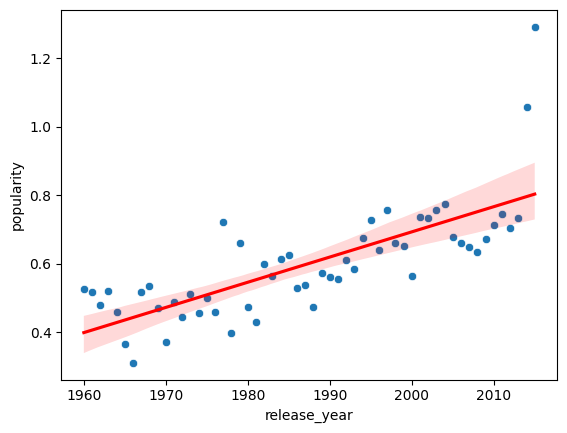

In [576]:
sns.scatterplot(data = popularity_year, x = popularity_year.index, y = 'popularity')
sns.regplot(data= popularity_year, x = popularity_year.index, y = 'popularity', scatter= False, color= 'red')

In [577]:
best_exploded = movies_exploded[movies_exploded['vote_average'] >= 8]
best_exploded.head()

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
Inside Out,150540,tt2096673,6.326804,175000000,853708609,94,Comedy,6/9/15,3935,8.0,2015,1.609999e+08,7.854116e+08
Inside Out,150540,tt2096673,6.326804,175000000,853708609,94,Animation,6/9/15,3935,8.0,2015,1.609999e+08,7.854116e+08
Inside Out,150540,tt2096673,6.326804,175000000,853708609,94,Family,6/9/15,3935,8.0,2015,1.609999e+08,7.854116e+08
Room,264644,tt3170832,3.557846,6000000,35401758,117,Drama,10/16/15,1520,8.0,2015,5.519998e+06,3.256960e+07
Room,264644,tt3170832,3.557846,6000000,35401758,117,Thriller,10/16/15,1520,8.0,2015,5.519998e+06,3.256960e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Schindler's List,424,tt0108052,2.377288,22000000,321265768,195,War,11/29/93,2632,8.1,1993,3.320834e+07,4.849410e+08
MacskafogÃ³,60800,tt0179955,0.195770,0,0,96,Animation,10/2/86,12,8.0,1986,0.000000e+00,0.000000e+00
MacskafogÃ³,60800,tt0179955,0.195770,0,0,96,Family,10/2/86,12,8.0,1986,0.000000e+00,0.000000e+00


In [578]:
best_exploded.groupby('genres')['genres'].value_counts().to_frame().sort_values('count', ascending= False)

,count
genres,
Documentary,34
Drama,30
Music,20
Comedy,14
Crime,12
Animation,9
Thriller,8
Family,7
Science Fiction,7


Question 4:
The genres with the most movies with a rating of more than 8 were Documentary, Drama, and Music.
This answers the questions I had. I'll still redo the analysis grouping by primary genre. I'm very curious on what some of the movies are though.

In [579]:
best_exploded.reset_index().set_index('genres').loc['Music']

,original_title,id,imdb_id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
genres,,,,,,,,,,,,,
Music,Whiplash,244786,tt2582802,4.780419,3300000,13993093,105,10/10/14,2372,8.2,2014,3.039600e+06,1.288891e+07
Music,Billy Elliot: The Musical,298931,tt4085696,0.097531,0,0,163,9/28/14,10,8.1,2014,0.000000e+00,0.000000e+00
Music,One Direction: Where We Are - The Concert,283559,tt3785068,0.004853,0,0,106,10/8/14,32,8.3,2014,0.000000e+00,0.000000e+00
Music,Iron Maiden: Flight 666,19105,tt1361558,0.103773,0,0,112,4/21/09,28,8.3,2009,0.000000e+00,0.000000e+00
Music,Rush: Beyond the Lighted Stage,41120,tt1545103,0.145026,0,0,107,6/29/10,14,8.4,2010,0.000000e+00,0.000000e+00
Music,Opeth: In Live Concert At The Royal Albert Hall,45644,NaN,0.067753,0,0,163,9/21/10,10,8.6,2010,0.000000e+00,0.000000e+00
Music,John Mayer: Where the Light Is Live in Los Ang...,20313,tt1270491,0.224721,0,0,164,7/1/08,16,8.5,2008,0.000000e+00,0.000000e+00
Music,Foo Fighters: Live at Wembley Stadium,22258,tt1321823,0.002475,0,0,120,8/25/08,10,8.4,2008,0.000000e+00,0.000000e+00
Music,George Harrison: Living in the Material World,75964,tt1113829,0.256142,0,0,208,10/5/11,24,8.0,2011,0.000000e+00,0.000000e+00


In [580]:
best_exploded.reset_index().set_index('genres').loc['Documentary']

,original_title,id,imdb_id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
genres,,,,,,,,,,,,,
Documentary,Hitting the Apex,357681,tt4973112,0.198522,0,0,138,9/2/15,14,8.0,2015,0.000000e+00,0.000000e+00
Documentary,Winter on Fire: Ukraine's Fight for Freedom,355020,tt4908644,0.220751,0,0,98,10/9/15,37,8.2,2015,0.000000e+00,0.000000e+00
Documentary,A Faster Horse,333350,tt3762974,0.122543,0,0,90,10/8/15,12,8.0,2015,0.000000e+00,0.000000e+00
Documentary,The Mask You Live In,224972,tt3983674,0.114264,0,0,88,1/1/15,11,8.9,2015,0.000000e+00,0.000000e+00
Documentary,The Fear of 13,367215,tt5083702,0.106091,0,0,96,10/15/15,19,8.2,2015,0.000000e+00,0.000000e+00
Documentary,The Jinx: The Life and Deaths of Robert Durst,321640,tt4299972,0.033378,0,0,240,2/8/15,72,8.4,2015,0.000000e+00,0.000000e+00
Documentary,One Direction: Where We Are - The Concert,283559,tt3785068,0.004853,0,0,106,10/8/14,32,8.3,2014,0.000000e+00,0.000000e+00
Documentary,Iron Maiden: Flight 666,19105,tt1361558,0.103773,0,0,112,4/21/09,28,8.3,2009,0.000000e+00,0.000000e+00
Documentary,Senna,58496,tt1424432,0.629432,0,8212430,106,10/7/10,178,8.0,2010,0.000000e+00,8.212430e+06


In [581]:
best_exploded.reset_index().set_index('genres').loc['Animation']

,original_title,id,imdb_id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
genres,,,,,,,,,,,,,
Animation,Inside Out,150540,tt2096673,6.326804,175000000,853708609,94,6/9/15,3935,8.0,2015,1.609999e+08,7.854116e+08
Animation,World of Tomorrow,303867,tt4171032,0.032678,0,0,17,3/31/15,47,8.2,2015,0.000000e+00,0.000000e+00
Animation,Song of the Sea,110416,tt1865505,1.376670,0,857522,93,9/6/14,263,8.0,2014,0.000000e+00,7.898558e+05
Animation,Feast,293299,tt3689498,0.705700,0,0,6,11/7/14,318,8.0,2014,0.000000e+00,0.000000e+00
Animation,Tick Tock Tale,352812,tt1736313,0.172275,0,0,6,6/10/10,13,8.3,2010,0.000000e+00,0.000000e+00
Animation,Presto,13042,tt1245104,0.905428,0,0,5,6/18/08,279,8.0,2008,0.000000e+00,0.000000e+00
Animation,The Maker,124277,tt1969151,0.013745,0,0,6,6/1/11,23,8.1,2011,0.000000e+00,0.000000e+00
Animation,Paperman,140420,tt2388725,1.182679,0,0,7,11/2/12,507,8.0,2012,0.000000e+00,0.000000e+00
Animation,MacskafogÃ³,60800,tt0179955,0.195770,0,0,96,10/2/86,12,8.0,1986,0.000000e+00,0.000000e+00


I'll now redo the analysis but I'll instead use the primary genre and by primary genre I mean the first genre that appears if there are multiple

In [ ]:
movies['genres'] = movies['genres'].str.split('|', expand= True).rename(columns= {0 : 'primary_genre'})['primary_genre']
movies.head()

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,124,Action,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
Mad Max: Fury Road,76341,tt1392190,28.419936,150000000,378436354,120,Action,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
Insurgent,262500,tt2908446,13.112507,110000000,295238201,119,Adventure,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
Star Wars: The Force Awakens,140607,tt2488496,11.173104,200000000,2068178225,136,Action,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
Furious 7,168259,tt2820852,9.335014,190000000,1506249360,137,Action,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
The Endless Summer,21,tt0060371,0.080598,0,0,95,Documentary,6/15/66,11,7.4,1966,0.000000e+00,0.000000e+00
Grand Prix,20379,tt0060472,0.065543,0,0,176,Action,12/21/66,20,5.7,1966,0.000000e+00,0.000000e+00
Beregis Avtomobilya,39768,tt0060161,0.065141,0,0,94,Mystery,1/1/66,11,6.5,1966,0.000000e+00,0.000000e+00


In [584]:
movies.groupby('genres')['genres'].value_counts().to_frame().sort_values('count', ascending= False)

,count
genres,
Drama,2453
Comedy,2319
Action,1590
Horror,915
Adventure,586
Thriller,491
Documentary,432
Animation,403
Crime,380


Question 1:
The most popular genres are Drama, Comedy, and Action. This differs from before where they were Drama, Comedy, and Thriller. This means that Thriller is more likely to be movie's secondary drama rather than its primary genre. 

In [585]:
movies.groupby('genres')[['budget_adj', 'revenue_adj']].mean().sort_values('budget_adj', ascending= False)   

,budget_adj,revenue_adj
genres,,
Adventure,4.829798e+07,1.665356e+08
Science Fiction,2.999102e+07,9.951810e+07
Action,2.947439e+07,7.401006e+07
Fantasy,2.729390e+07,8.283760e+07
Western,2.627058e+07,4.730739e+07
War,2.556366e+07,4.874310e+07
History,2.318089e+07,6.536195e+07
Animation,2.295937e+07,7.671443e+07
Family,2.060432e+07,7.724863e+07


In [586]:
movies.groupby('genres')[['budget_adj', 'revenue_adj']].mean().sort_values('revenue_adj', ascending= False)  

,budget_adj,revenue_adj
genres,,
Adventure,4.829798e+07,1.665356e+08
Science Fiction,2.999102e+07,9.951810e+07
Fantasy,2.729390e+07,8.283760e+07
Family,2.060432e+07,7.724863e+07
Animation,2.295937e+07,7.671443e+07
Action,2.947439e+07,7.401006e+07
History,2.318089e+07,6.536195e+07
War,2.556366e+07,4.874310e+07
Western,2.627058e+07,4.730739e+07


The highest budget movies were Adventure, Science Fiction, and Action. While the highest revenue movies were Adventure, Science Fiction and Fantasy. With the other system, the top movies by both budget and revenue were Adventure, Fantasy, and Action. The results seem pretty similar between rankings. The biggest difference is that Action ranked 6th in terms of revenue while it was ranked 3rd with the previous metric.

In [587]:
movies.groupby('genres')['popularity'].mean().to_frame().sort_values('popularity', ascending= False)

,popularity
genres,
Adventure,1.217868
Science Fiction,1.073096
Fantasy,0.865390
Action,0.836394
Animation,0.810370
War,0.767041
History,0.764636
Family,0.730987
Romance,0.704157


Question 3:
The most popular genres were Adventure, Science Fiction and Fantasy which was the same ranking as in the old metric.

In [588]:
best_movies= movies[movies['vote_average'] >= 8]
best_movies.head()

,id,imdb_id,popularity,budget,revenue,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,
Inside Out,150540,tt2096673,6.326804,175000000,853708609,94,Comedy,6/9/15,3935,8.0,2015,1.609999e+08,7.854116e+08
Room,264644,tt3170832,3.557846,6000000,35401758,117,Drama,10/16/15,1520,8.0,2015,5.519998e+06,3.256960e+07
Hitting the Apex,357681,tt4973112,0.198522,0,0,138,Documentary,9/2/15,14,8.0,2015,0.000000e+00,0.000000e+00
Winter on Fire: Ukraine's Fight for Freedom,355020,tt4908644,0.220751,0,0,98,Documentary,10/9/15,37,8.2,2015,0.000000e+00,0.000000e+00
A Faster Horse,333350,tt3762974,0.122543,0,0,90,Documentary,10/8/15,12,8.0,2015,0.000000e+00,0.000000e+00


In [589]:
best_movies.groupby('genres')['genres'].value_counts().to_frame().sort_values('count', ascending= False)

,count
genres,
Documentary,27
Drama,19
Comedy,10
Music,10
Animation,5
Adventure,3
Crime,3
Horror,2
Science Fiction,2


The genres with the most movies with ratings over 8 were Documentary, Drama, and Comedy. With the old metric it was Documentary, Drama, and Music. I believe this difference is caused by the fact that in the old metric many movies that were documentaries about musicians were labeled as both Documentary and Drama while here they are being labeled as Documentaries. 

In [590]:
best_exploded.reset_index().set_index('genres').loc['Music']

,original_title,id,imdb_id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
genres,,,,,,,,,,,,,
Music,Whiplash,244786,tt2582802,4.780419,3300000,13993093,105,10/10/14,2372,8.2,2014,3.039600e+06,1.288891e+07
Music,Billy Elliot: The Musical,298931,tt4085696,0.097531,0,0,163,9/28/14,10,8.1,2014,0.000000e+00,0.000000e+00
Music,One Direction: Where We Are - The Concert,283559,tt3785068,0.004853,0,0,106,10/8/14,32,8.3,2014,0.000000e+00,0.000000e+00
Music,Iron Maiden: Flight 666,19105,tt1361558,0.103773,0,0,112,4/21/09,28,8.3,2009,0.000000e+00,0.000000e+00
Music,Rush: Beyond the Lighted Stage,41120,tt1545103,0.145026,0,0,107,6/29/10,14,8.4,2010,0.000000e+00,0.000000e+00
Music,Opeth: In Live Concert At The Royal Albert Hall,45644,NaN,0.067753,0,0,163,9/21/10,10,8.6,2010,0.000000e+00,0.000000e+00
Music,John Mayer: Where the Light Is Live in Los Ang...,20313,tt1270491,0.224721,0,0,164,7/1/08,16,8.5,2008,0.000000e+00,0.000000e+00
Music,Foo Fighters: Live at Wembley Stadium,22258,tt1321823,0.002475,0,0,120,8/25/08,10,8.4,2008,0.000000e+00,0.000000e+00
Music,George Harrison: Living in the Material World,75964,tt1113829,0.256142,0,0,208,10/5/11,24,8.0,2011,0.000000e+00,0.000000e+00


In [591]:
best_movies.reset_index().set_index('genres').loc['Music']

,original_title,id,imdb_id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
genres,,,,,,,,,,,,,
Music,Opeth: In Live Concert At The Royal Albert Hall,45644,NaN,0.067753,0,0,163,9/21/10,10,8.6,2010,0.0,0.000000e+00
Music,John Mayer: Where the Light Is Live in Los Ang...,20313,tt1270491,0.224721,0,0,164,7/1/08,16,8.5,2008,0.0,0.000000e+00
Music,Foo Fighters: Live at Wembley Stadium,22258,tt1321823,0.002475,0,0,120,8/25/08,10,8.4,2008,0.0,0.000000e+00
Music,George Harrison: Living in the Material World,75964,tt1113829,0.256142,0,0,208,10/5/11,24,8.0,2011,0.0,0.000000e+00
Music,One Direction: Up All Night - The Live Tour,111349,tt2178476,0.162227,0,0,73,5/16/12,10,8.3,2012,0.0,0.000000e+00
Music,Tupac: Resurrection,21525,tt0343121,0.238250,0,7808524,112,1/23/03,15,8.0,2003,0.0,9.255855e+06
Music,Tropico,241287,tt3384034,0.107333,0,0,27,12/5/13,24,8.4,2013,0.0,0.000000e+00
Music,Pink Floyd: Pulse,24970,tt0110758,0.212010,0,0,145,7/9/06,23,8.7,2006,0.0,0.000000e+00
Music,Queen - Rock Montreal,25093,tt1421377,0.302908,0,0,138,11/24/81,14,8.5,1981,0.0,0.000000e+00


In [592]:
best_movies.reset_index().set_index('genres').loc['Documentary']

,original_title,id,imdb_id,popularity,budget,revenue,runtime,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
genres,,,,,,,,,,,,,
Documentary,Hitting the Apex,357681,tt4973112,0.198522,0,0,138,9/2/15,14,8.0,2015,0.000000e+00,0.000000e+00
Documentary,Winter on Fire: Ukraine's Fight for Freedom,355020,tt4908644,0.220751,0,0,98,10/9/15,37,8.2,2015,0.000000e+00,0.000000e+00
Documentary,A Faster Horse,333350,tt3762974,0.122543,0,0,90,10/8/15,12,8.0,2015,0.000000e+00,0.000000e+00
Documentary,The Mask You Live In,224972,tt3983674,0.114264,0,0,88,1/1/15,11,8.9,2015,0.000000e+00,0.000000e+00
Documentary,The Jinx: The Life and Deaths of Robert Durst,321640,tt4299972,0.033378,0,0,240,2/8/15,72,8.4,2015,0.000000e+00,0.000000e+00
Documentary,One Direction: Where We Are - The Concert,283559,tt3785068,0.004853,0,0,106,10/8/14,32,8.3,2014,0.000000e+00,0.000000e+00
Documentary,Iron Maiden: Flight 666,19105,tt1361558,0.103773,0,0,112,4/21/09,28,8.3,2009,0.000000e+00,0.000000e+00
Documentary,Senna,58496,tt1424432,0.629432,0,8212430,106,10/7/10,178,8.0,2010,0.000000e+00,8.212430e+06
Documentary,Life Cycles,51299,tt1828232,0.222293,0,0,47,10/2/10,27,8.8,2010,0.000000e+00,0.000000e+00


Whiplash, Billy Elliot: the Musical, One Direction: Where We Are - The Concert, Iron Maiden: Flight 666, Rush: Beyond the Lighted Stage, One Direction: This Is Us, Metal: A Headbanger's Journey, Stop Making Sense, Michael Jackson's Thriller, The Last Waltz were all had music as their primary genre but not their secondary. Of these 7 were classified as just documentaries. 